# Build the selected-eddy fixed-core cache

Calculate the ESP-Gaussian surface PV-gradient terms for the supplied eight AEs and four CEs only. Run this first after changing the selected eddy list.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE=Path.cwd().resolve()
ANALYSIS_ROOT=next((p for p in (HERE,*HERE.parents) if (p/"seacofs_tilt_tools.py").exists()),None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError("Run inside seacofs_eddy_tilt_analysis or a subfolder")
CASE_ROOT=ANALYSIS_ROOT/"case_studies"
for path in (ANALYSIS_ROOT,CASE_ROOT,HERE):
    if str(path) not in sys.path: sys.path.insert(0,str(path))
import seacofs_tilt_tools as tilt
import selected_case_tools as cases
sns.set_theme(style="whitegrid",context="notebook")


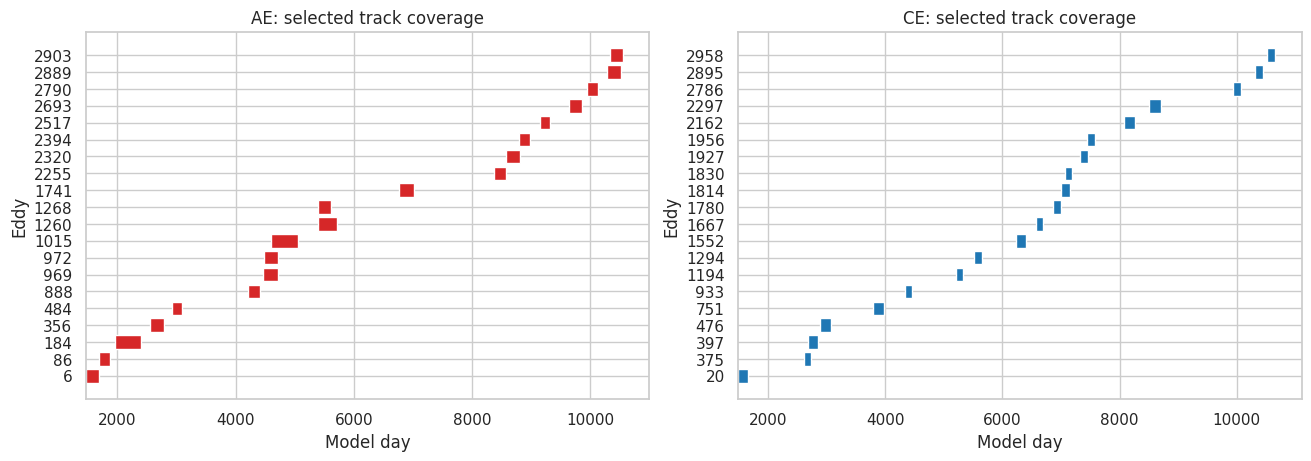

In [2]:
paths=tilt.Paths()
grid=tilt.load_grid(paths.grid,paths.z_r)
eddies,_=tilt.load_tilt_tables(paths)
selected=cases.select_tracks(eddies)

inventory=(selected.groupby(["Cyc","Eddy"]).agg(first_day=("Day","min"),last_day=("Day","max"),snapshots=("Day","size")).reset_index())
fig,axes=plt.subplots(1,2,figsize=(13,4.5),constrained_layout=True)
for ax,cyc in zip(axes,["AE","CE"]):
    part=inventory[inventory.Cyc.eq(cyc)]
    ax.barh(part.Eddy.astype(str),part.last_day-part.first_day,left=part.first_day,color="tab:red" if cyc=="AE" else "tab:blue")
    ax.set(xlabel="Model day",ylabel="Eddy",title=f"{cyc}: selected track coverage")
plt.show()

In [3]:
data=cases.build_cache(eddies,grid)
destination=cases.cache_path(); destination.parent.mkdir(parents=True,exist_ok=True)
data.to_parquet(destination,index=False)

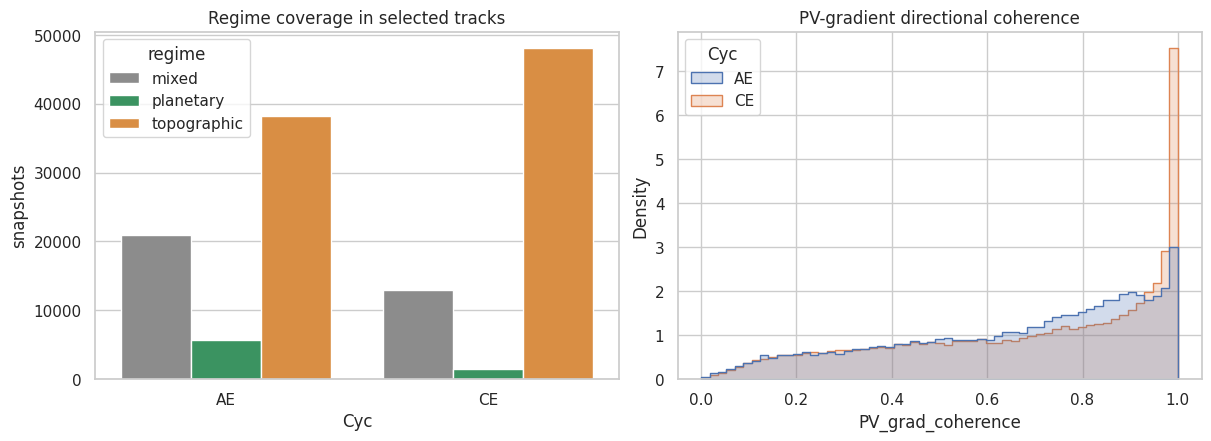

In [4]:
counts=data.groupby(["Cyc","regime"]).size().rename("snapshots").reset_index()
fig,axes=plt.subplots(1,2,figsize=(12,4.3),constrained_layout=True)
sns.barplot(data=counts,x="Cyc",y="snapshots",hue="regime",palette=cases.REGIME_COLOURS,ax=axes[0])
sns.histplot(data=data,x="PV_grad_coherence",hue="Cyc",element="step",stat="density",common_norm=False,ax=axes[1])
axes[0].set_title("Regime coverage in selected tracks"); axes[1].set_title("PV-gradient directional coherence")
plt.show()